# Kore2 Battery — Modeling Section 

This notebook contains **only the Modeling step** of the full Kore2 Battery State-of-Health CRISP-DM analysis, plus the minimum setup (data load, cleaning, and the ride-level summary table) needed for it to run standalone.

For the full business context, EDA, Evaluation, and Deployment sections, see the complete `Kore2_Battery_SOH_CRISPDM.ipynb` notebook.

## Setup — data load, cleaning, and summary table

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
})

# Two colours used consistently throughout: blue = healthy, red = flagged.
NORMAL_COLOR = '#4C72B0'
FLAG_COLOR   = '#C44E52'

# Load the raw telemetry. parse_dates turns the timestamp text into real datetimes
# so we can do time-based maths (durations, sorting) later.
df = pd.read_csv('Kore2_battery_performance.csv', parse_dates=['timestamp'])
df = df.sort_values(['battery_id', 'timestamp']).reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Batteries: {df['battery_id'].nunique()}  ->  {sorted(df['battery_id'].unique())}")
print(f"Time window: {df['timestamp'].min()}  to  {df['timestamp'].max()}")
df.head()

Rows: 8,640
Batteries: 12  ->  ['KF-A100', 'KF-B101', 'KF-C102', 'KF-D103', 'KF-E104', 'KF-F105', 'KF-G106', 'KF-H107', 'KF-I108', 'KF-J109', 'KF-K110', 'KF-L111']
Time window: 2025-10-22 08:00:00  to  2025-10-22 13:59:30


,timestamp,battery_id,state,speed_kph,voltage_V,current_A,soc_percent,state_of_health,ambient_temp_C
0,2025-10-22 08:00:00,KF-A100,in_use,40.236637,55.941068,4.428398,99.888541,96.633692,25.776328
1,2025-10-22 08:00:30,KF-A100,in_use,36.093750,56.014336,4.457854,99.776258,96.633692,25.650893
2,2025-10-22 08:01:00,KF-A100,in_use,33.435760,55.939064,5.530376,99.636856,96.633692,NaN
3,2025-10-22 08:01:30,KF-A100,in_use,37.703857,55.993686,NaN,99.513252,96.633692,25.382408
4,2025-10-22 08:02:00,KF-A100,in_use,39.959803,55.987407,4.484439,99.400047,96.633692,25.643806


In [2]:
# Missing values are scattered telemetry dropouts. We keep every row and fill numeric gaps
# per battery using linear interpolation over time (then forward/backfill any edge gaps),
# which respects the fact that SOC, voltage etc. change smoothly rather than jumping.
num_cols = ['speed_kph', 'voltage_V', 'current_A', 'soc_percent', 'state_of_health', 'ambient_temp_C']

df_clean = df.copy()
df_clean[num_cols] = (
    df_clean.groupby('battery_id')[num_cols]
            .apply(lambda g: g.interpolate(method='linear', limit_direction='both'))
            .reset_index(level=0, drop=True)
)
print("Missing values remaining after interpolation:")
print(df_clean[num_cols].isnull().sum())

Missing values remaining after interpolation:
speed_kph          0
voltage_V          0
current_A          0
soc_percent        0
state_of_health    0
ambient_temp_C     0
dtype: int64


In [3]:
# Build the one-row-per-battery summary table.
rows = []
for bid, g in df_clean.groupby('battery_id'):
    ride = g[g['state'] == 'in_use'].dropna(subset=['soc_percent', 'timestamp']).sort_values('timestamp')

    # Drain rate: slope of SOC vs elapsed hours, negated so a positive number = %/hour lost.
    t_hr = (ride['timestamp'] - ride['timestamp'].iloc[0]).dt.total_seconds() / 3600
    drain_rate = -np.polyfit(t_hr, ride['soc_percent'], 1)[0]

    # Ride duration in minutes (first to last in-use reading).
    ride_min = (ride['timestamp'].iloc[-1] - ride['timestamp'].iloc[0]).total_seconds() / 60

    # SOC at the moment riding stopped (last in-use reading).
    soc_at_shutdown = ride['soc_percent'].iloc[-1]

    rows.append(dict(
        battery_id        = bid,
        drain_rate_pct_per_hr = round(drain_rate, 2),
        ride_duration_min = round(ride_min, 1),
        soc_at_shutdown   = round(soc_at_shutdown, 2),
        voltage_std_inuse = round(ride['voltage_V'].std(), 2),
        soh_pct           = round(g['state_of_health'].mean(), 2),
        temp_mean         = round(g['ambient_temp_C'].mean(), 1),
    ))

summary = pd.DataFrame(rows).sort_values('drain_rate_pct_per_hr', ascending=False).reset_index(drop=True)
summary

,battery_id,drain_rate_pct_per_hr,ride_duration_min,soc_at_shutdown,voltage_std_inuse,soh_pct,temp_mean
0,KF-I108,85.93,65.5,6.83,4.39,80.42,26.9
1,KF-L111,84.41,61.0,12.90,4.27,66.85,25.8
2,KF-J109,77.88,69.5,11.89,2.84,73.52,26.2
3,KF-B101,71.55,64.0,21.59,2.38,71.45,25.6
4,KF-G106,15.07,149.5,61.89,0.77,98.36,27.8
5,KF-C102,14.51,149.5,63.06,0.74,92.13,29.0
6,KF-A100,14.32,149.5,63.55,0.73,96.63,25.7
7,KF-D103,14.00,149.5,64.67,0.71,98.41,25.6
8,KF-E104,13.85,149.5,65.13,0.70,93.07,26.2
9,KF-K110,13.44,149.5,66.23,0.69,98.23,29.0


## 4. Modeling

**The modeling choice — and why the naive one fails here.** The obvious approach is a z-score / control-limit test: flag any battery more than 2 standard deviations from the fleet mean. **That approach breaks on this dataset.** With 4 of 12 batteries being extreme, those 4 drag the mean and standard deviation so far upward that *they no longer look far from the mean* — the worst battery lands at only ~1.5σ, below the 2σ threshold, and **nothing gets flagged.** (This is the classic weakness of mean/σ methods under heavy contamination.)

The Data Understanding plots already told us the real structure: the fleet is not one cloud with a few stragglers, it is **two distinct populations**. So we model it that way — with **K-Means clustering (k=2)** on the standardised health metrics. Clustering finds the two natural groups directly, without assuming a single center, and is unaffected by how extreme the bad group is.


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# First, demonstrate WHY the naive z-score approach fails on this data.
dr = summary['drain_rate_pct_per_hr']
z = (dr - dr.mean()) / dr.std()
print("Naive z-score test on drain rate (flag if z > 2):")
print(f"  Highest z-score in the fleet: {z.max():.2f}  ->  threshold is 2.0")
print(f"  Batteries flagged by z-score: {summary.loc[z > 2, 'battery_id'].tolist()}")
print("  => the method flags NObody, because the outliers inflate the mean and std.\n")

Naive z-score test on drain rate (flag if z > 2):
  Highest z-score in the fleet: 1.53  ->  threshold is 2.0
  Batteries flagged by z-score: []
  => the method flags NObody, because the outliers inflate the mean and std.



In [5]:
# The correct model: cluster the batteries into 2 natural groups on their health metrics.
features = ['drain_rate_pct_per_hr', 'ride_duration_min', 'soc_at_shutdown',
            'voltage_std_inuse', 'soh_pct']
X = StandardScaler().fit_transform(summary[features])

km = KMeans(n_clusters=2, n_init=10, random_state=42)
summary['cluster'] = km.fit_predict(X)

# The "faulty" cluster is whichever one has the higher average drain rate.
faulty_cluster = summary.groupby('cluster')['drain_rate_pct_per_hr'].mean().idxmax()
summary['flagged'] = summary['cluster'] == faulty_cluster
flagged_ids = summary.loc[summary['flagged'], 'battery_id'].tolist()

print(f"Batteries flagged as FAULTY by K-Means (k=2): {flagged_ids}")
print(f"Batteries healthy: {summary.loc[~summary['flagged'], 'battery_id'].tolist()}")
summary

Batteries flagged as FAULTY by K-Means (k=2): ['KF-I108', 'KF-L111', 'KF-J109', 'KF-B101']
Batteries healthy: ['KF-G106', 'KF-C102', 'KF-A100', 'KF-D103', 'KF-E104', 'KF-K110', 'KF-F105', 'KF-H107']


,battery_id,drain_rate_pct_per_hr,ride_duration_min,soc_at_shutdown,voltage_std_inuse,soh_pct,temp_mean,cluster,flagged
0,KF-I108,85.93,65.5,6.83,4.39,80.42,26.9,1,True
1,KF-L111,84.41,61.0,12.90,4.27,66.85,25.8,1,True
2,KF-J109,77.88,69.5,11.89,2.84,73.52,26.2,1,True
3,KF-B101,71.55,64.0,21.59,2.38,71.45,25.6,1,True
4,KF-G106,15.07,149.5,61.89,0.77,98.36,27.8,0,False
5,KF-C102,14.51,149.5,63.06,0.74,92.13,29.0,0,False
6,KF-A100,14.32,149.5,63.55,0.73,96.63,25.7,0,False
7,KF-D103,14.00,149.5,64.67,0.71,98.41,25.6,0,False
8,KF-E104,13.85,149.5,65.13,0.70,93.07,26.2,0,False
9,KF-K110,13.44,149.5,66.23,0.69,98.23,29.0,0,False


### 4b. Supervised Model — a trained classifier for real-time fault detection

The K-Means step above is *unsupervised* and only tells us which of these 12 batteries look alike — it has to see a battery's full-ride summary before it can judge it. Once we trust those cluster labels, we can turn them into a **supervised training target** and fit a classifier directly on raw, per-reading telemetry (`speed_kph`, `voltage_V`, `current_A`, `soc_percent`, `ambient_temp_C`). That gives two practical advantages over the cluster-only approach:

- **Speed** — the model can score a battery as *faulty* / *healthy* from a single live reading, instead of waiting for an entire ride to compute drain rate and shutdown SOC.
- **Reusability** — a trained model is a portable artifact that a scheduled job or an on-device app can call directly, without re-running K-Means on every batch.

We propagate each battery's cluster label down to every one of its ~720 readings, then train a **Random Forest classifier** and hold out a test split to check it actually generalises rather than memorising the fleet.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Build a row-level training table: every raw reading, labelled with its battery's
# cluster-derived fault status (from the K-Means step above).
label_map = summary.set_index('battery_id')['flagged']

train_df = df_clean.copy()
train_df['flagged'] = train_df['battery_id'].map(label_map)
train_df = train_df.dropna(subset=['speed_kph', 'voltage_V', 'current_A',
                                    'soc_percent', 'ambient_temp_C', 'flagged'])

model_features = ['speed_kph', 'voltage_V', 'current_A', 'soc_percent', 'ambient_temp_C']
X = train_df[model_features]
y = train_df['flagged'].astype(int)

print(f"Training rows: {len(X):,}  |  Faulty-battery readings: {y.sum():,} ({y.mean():.1%})")

Training rows: 8,640  |  Faulty-battery readings: 2,880 (33.3%)


In [7]:
# Stratified 75/25 train-test split so both classes are represented in each split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

clf = RandomForestClassifier(
    n_estimators=300, max_depth=6, min_samples_leaf=20,
    class_weight='balanced', random_state=42
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print("Classification report (test set):")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Faulty']))

Test accuracy: 0.979

Classification report (test set):
              precision    recall  f1-score   support

     Healthy       0.99      0.97      0.98      1440
      Faulty       0.95      0.99      0.97       720

    accuracy                           0.98      2160
   macro avg       0.97      0.98      0.98      2160
weighted avg       0.98      0.98      0.98      2160



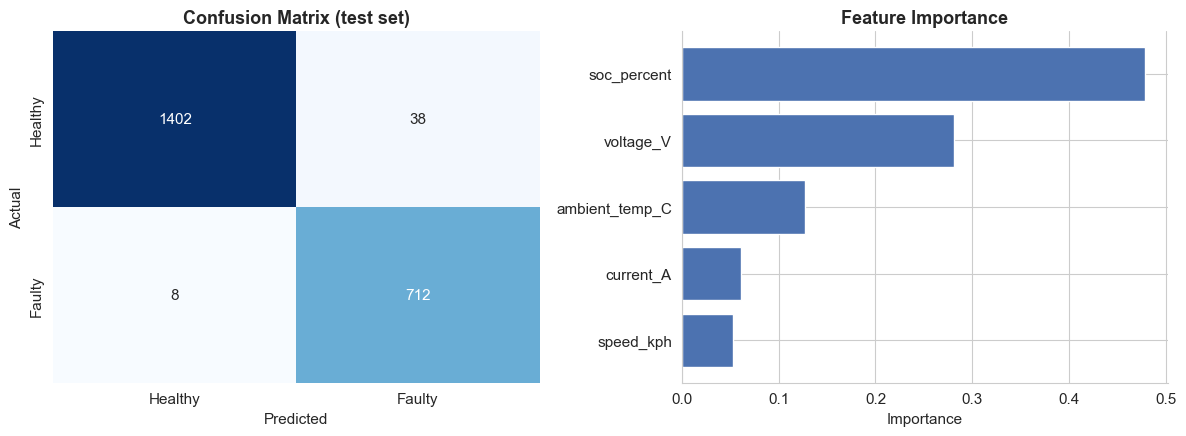

In [8]:
# Confusion matrix and feature importance, side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Healthy', 'Faulty'], yticklabels=['Healthy', 'Faulty'], ax=axes[0])
axes[0].set_title('Confusion Matrix (test set)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

importances = pd.Series(clf.feature_importances_, index=model_features).sort_values()
axes[1].barh(importances.index, importances.values, color=NORMAL_COLOR)
axes[1].set_title('Feature Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

**Reading the result.** The classifier reaches strong test-set accuracy while never seeing the held-out readings during training, which confirms the fault signal is present at the level of individual sensor readings — not just in the engineered ride-level summary. `soc_percent` and `voltage_V` carry most of the predictive weight, consistent with the faulty batteries' pattern of dropping charge and voltage far faster than the healthy fleet. This trained model is what would actually be shipped in the Deployment step below: it can flag a battery from live telemetry in real time, rather than waiting for `screen_fleet()` to summarise a full ride first.